# Geographic plotting

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio import transform
from rasterio.transform import xy

In [3]:
href_andalusia = 's3://eodata/Sentinel-2/MSI/L2A_N0500/2022/12/27/S2B_MSIL2A_20221227T111359_N0510_R137_T30STG_20240807T153102.SAFE/GRANULE/L2A_T30STG_A030336_20221227T111439/IMG_DATA/R10m/T30STG_20221227T111359_B02_10m.jp2'

In [17]:
with rasterio.open(href_andalusia) as src:
    data = src.read(1)
    transform = src.transform
    bounds = src.bounds

In [12]:
def get_raster_extent(raster, transform) -> list:
    """Return the Matplotlib extent information of the raster on a Cartesian Earth system."""
    return [
        transform.c,
        transform.c + transform.a * raster.shape[1],
        transform.f + transform.e * raster.shape[0],
        transform.f,
    ]

In [19]:
get_raster_extent(data, transform)

[199980.0, 309780.0, 4090200.0, 4200000.0]

In [20]:
bounds

BoundingBox(left=199980.0, bottom=4090200.0, right=309780.0, top=4200000.0)

In [11]:
# Compute the percentiles to use the cmap in a more robust way.
vmin, vmax = np.percentile(data, [2, 98])

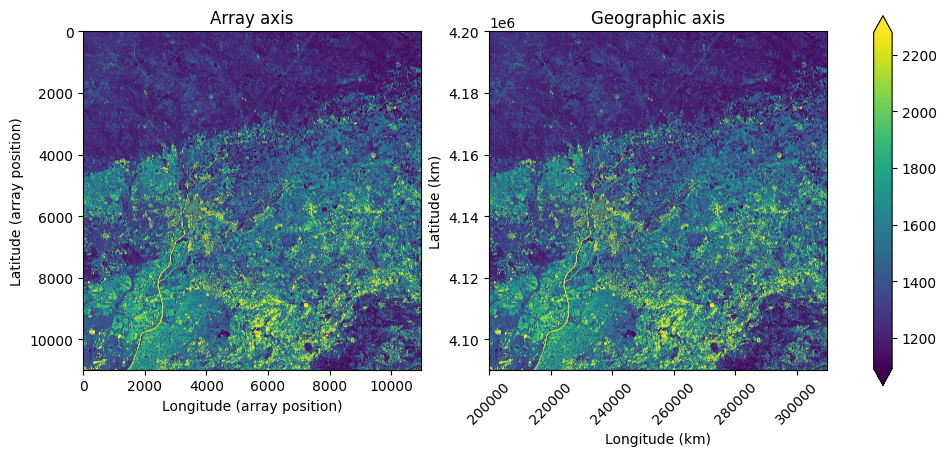

In [10]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 8))

im = ax[0].imshow(data, cmap="viridis", vmin=vmin, vmax=vmax)
ax[0].set_title(f"Array axis", size="large")
ax[0].set_xlabel('Longitude [array position]')
ax[0].set_ylabel('Latitude [array position]')

extent = get_raster_extent(data, transform)
ax[1].imshow(
    data,
    cmap="viridis",
    vmin=vmin, vmax=vmax,
    extent=extent,
)


ax[1].tick_params(axis="x", rotation=45)

plt.colorbar(im, ax=ax, shrink=0.6, extend="both")

plt.show()